# Olist - Delivery Feature Exploration

**Goal:** explore purchase-time signals that may predict whether a delivered order arrives after the customer-facing estimated delivery date (`late = 1`).

**Dataset:** Olist Brazilian e-commerce order, item, payment, product, seller, customer, and geolocation tables.

This notebook builds a leakage-safe, order-level feature table, documents the candidate feature inventory, and inspects relationships with the late-delivery target before model benchmarking. Post-purchase delivery timestamps are used only to define the historical target, not as model inputs.

In [27]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Locate the data dir whether we launch from repo root or notebooks/
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# ---------------------------------------------------------------------------
# Feature groups explored in this notebook
# ---------------------------------------------------------------------------
NUMERIC_FEATURES = [
    "estimated_delivery_days",
    "shipping_limit_days",
    "shipping_limit_days_min",
    "shipping_limit_days_range",
    "n_unique_shipping_limits",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "n_items",
    "n_distinct_products",
    "n_product_categories",
    "n_sellers",
    "price_total",
    "freight_total",
    "freight_ratio",
    "product_weight_g_total",
    "product_volume_cm3_total",
    "product_photos_qty_avg",
    "product_description_length_avg",
    "payment_installments_max",
    "payment_value_total",
    "geo_distance_km",
    "same_state",
]
CATEGORICAL_FEATURES = [
    "customer_state",
    "customer_city",
    "seller_state",
    "seller_city",
    "payment_type",
    "primary_product_category",
]
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET_COLUMN = "late"
TIME_COLUMN = "order_purchase_timestamp"

# ---------------------------------------------------------------------------
# 0. Load the raw Olist tables
# ---------------------------------------------------------------------------
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
order_payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
geolocation = pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv")


def _haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two arrays of lat/lon points."""
    r = 6371.0
    lat1, lon1, lat2, lon2 = (np.radians(x) for x in (lat1, lon1, lat2, lon2))
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return r * 2 * np.arcsin(np.sqrt(a))


# ---------------------------------------------------------------------------
# 1. Target + purchase-time temporal features (from `orders`)
# ---------------------------------------------------------------------------
for col in [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]:
    orders[col] = pd.to_datetime(orders[col])

delivered = orders[orders["order_status"] == "delivered"].dropna(
    subset=["order_delivered_customer_date", "order_estimated_delivery_date"]
)
df = delivered[
    [
        "order_id",
        "customer_id",
        "order_purchase_timestamp",
        "order_estimated_delivery_date",
        "order_delivered_customer_date",
    ]
].copy()

# Target: delivered after the customer-facing estimate.
# We treat `order_estimated_delivery_date` as the delivery deadline/limit (it is
# stored at midnight of the promised day). A strict `>` flags any delivery after
# that instant as late, so same-day deliveries after 00:00 also count as late by
# design ("deliver by this date/time", not "any time on this date is fine").
df[TARGET_COLUMN] = (
    df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]
).astype(int)

purchase = df["order_purchase_timestamp"]
df["estimated_delivery_days"] = (
    df["order_estimated_delivery_date"] - purchase
).dt.total_seconds() / 86400.0
df["purchase_month"] = purchase.dt.month
df["purchase_dayofweek"] = purchase.dt.dayofweek
df["purchase_hour"] = purchase.dt.hour

# ---------------------------------------------------------------------------
# 2. Order-item + product aggregates (one row per order)
# ---------------------------------------------------------------------------
products_enriched = products.merge(
    category_translation,
    on="product_category_name",
    how="left",
)
products_enriched["product_category_name_english"] = products_enriched[
    "product_category_name_english"
].fillna(products_enriched["product_category_name"])

items = order_items.merge(
    products_enriched[
        [
            "product_id",
            "product_category_name_english",
            "product_photos_qty",
            "product_description_lenght",
            "product_weight_g",
            "product_length_cm",
            "product_height_cm",
            "product_width_cm",
        ]
    ],
    on="product_id",
    how="left",
)
items["product_volume_cm3"] = (
    items["product_length_cm"] * items["product_height_cm"] * items["product_width_cm"]
)
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"])

def _nunique_or_nan(s):
    """Count distinct known values; return NaN when every value is missing."""
    return s.nunique() if s.notna().any() else np.nan


item_feats = items.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    n_distinct_products=("product_id", "nunique"),
    n_product_categories=("product_category_name_english", _nunique_or_nan),
    n_sellers=("seller_id", "nunique"),
    price_total=("price", "sum"),
    freight_total=("freight_value", "sum"),
    product_weight_g_total=("product_weight_g", lambda s: s.sum(min_count=1)),
    product_volume_cm3_total=("product_volume_cm3", lambda s: s.sum(min_count=1)),
    product_photos_qty_avg=("product_photos_qty", "mean"),
    product_description_length_avg=("product_description_lenght", "mean"),
    shipping_limit_date=("shipping_limit_date", "max"),
    shipping_limit_date_min=("shipping_limit_date", "min"),
    n_unique_shipping_limits=("shipping_limit_date", "nunique"),
)
item_feats["freight_ratio"] = item_feats["freight_total"] / (item_feats["price_total"] + 1.0)

# Primary item fields = first line item, used for geography and category exploration.
first_item = items.sort_values("order_item_id").groupby("order_id").agg(
    primary_seller_id=("seller_id", "first"),
    primary_product_category=("product_category_name_english", "first"),
)
item_feats = item_feats.join(first_item)

# ---------------------------------------------------------------------------
# 3. Payment aggregates (one row per order)
# ---------------------------------------------------------------------------
pay_feats = order_payments.groupby("order_id").agg(
    payment_value_total=("payment_value", "sum"),
    payment_installments_max=("payment_installments", "max"),
)
dominant_type = (
    order_payments.sort_values("payment_value", ascending=False)
    .groupby("order_id")["payment_type"]
    .first()
    .rename("payment_type")
)
pay_feats = pay_feats.join(dominant_type)

df = df.merge(item_feats, on="order_id", how="left").merge(
    pay_feats, on="order_id", how="left"
)
df["shipping_limit_days"] = (
    df["shipping_limit_date"] - df["order_purchase_timestamp"]
).dt.total_seconds() / 86400.0
df["shipping_limit_days_min"] = (
    df["shipping_limit_date_min"] - df["order_purchase_timestamp"]
).dt.total_seconds() / 86400.0
df["shipping_limit_days_range"] = df["shipping_limit_days"] - df["shipping_limit_days_min"]

# ---------------------------------------------------------------------------
# 4. Geography: customer & primary-seller states/cities + centroid distance
# ---------------------------------------------------------------------------
df = df.merge(
    customers[["customer_id", "customer_state", "customer_city", "customer_zip_code_prefix"]],
    on="customer_id",
    how="left",
)
sellers_geo = sellers[
    ["seller_id", "seller_state", "seller_city", "seller_zip_code_prefix"]
].rename(columns={"seller_id": "primary_seller_id"})
df = df.merge(sellers_geo, on="primary_seller_id", how="left")
# Leave `same_state` as NaN when either state is unknown, rather than
# asserting "different state" for a failed join.
both_states_known = df["customer_state"].notna() & df["seller_state"].notna()
df["same_state"] = (
    (df["customer_state"] == df["seller_state"]).where(both_states_known).astype("float")
)

# Mean lat/lng per zip-code prefix (geolocation has many rows per zip).
# Drop coordinates outside continental Brazil first: a few corrupt Olist rows
# otherwise inflate geo_distance_km to physically impossible values (>8,000 km).
BRAZIL_LAT_BOUNDS = (-33.75, 5.27)
BRAZIL_LNG_BOUNDS = (-73.99, -34.79)
in_brazil = geolocation["geolocation_lat"].between(*BRAZIL_LAT_BOUNDS) & geolocation[
    "geolocation_lng"
].between(*BRAZIL_LNG_BOUNDS)
centroids = (
    geolocation[in_brazil]
    .groupby("geolocation_zip_code_prefix")
    .agg(lat=("geolocation_lat", "mean"), lng=("geolocation_lng", "mean"))
    .reset_index()
)
cust_geo = centroids.rename(
    columns={"geolocation_zip_code_prefix": "customer_zip_code_prefix", "lat": "c_lat", "lng": "c_lng"}
)
sell_geo = centroids.rename(
    columns={"geolocation_zip_code_prefix": "seller_zip_code_prefix", "lat": "s_lat", "lng": "s_lng"}
)
df = df.merge(cust_geo, on="customer_zip_code_prefix", how="left").merge(
    sell_geo, on="seller_zip_code_prefix", how="left"
)
df["geo_distance_km"] = _haversine_km(df["c_lat"], df["c_lng"], df["s_lat"], df["s_lng"])

# ---------------------------------------------------------------------------
# 5. Final leakage-safe exploration table
# ---------------------------------------------------------------------------
df = (
    df[[TIME_COLUMN, TARGET_COLUMN, *FEATURE_COLUMNS]]
    .sort_values(TIME_COLUMN)
    .reset_index(drop=True)
)

print(f"rows: {len(df):,}  |  columns: {df.shape[1]}")
print(f"time range: {df[TIME_COLUMN].min():%Y-%m-%d} → {df[TIME_COLUMN].max():%Y-%m-%d}")
df.head()

rows: 96,470  |  columns: 31
time range: 2016-09-15 → 2018-08-29


,order_purchase_timestamp,late,estimated_delivery_days,shipping_limit_days,shipping_limit_days_min,shipping_limit_days_range,n_unique_shipping_limits,purchase_month,purchase_dayofweek,purchase_hour,...,payment_installments_max,payment_value_total,geo_distance_km,same_state,customer_state,customer_city,seller_state,seller_city,payment_type,primary_product_category
0,2016-09-15 12:16:38,1,18.488,4.455,4.455,0.000,1,9,3,12,...,NaN,NaN,565.960,0.000,SP,sao joaquim da barra,PR,curitiba,NaN,health_beauty
1,2016-10-03 09:44:50,0,23.594,18.280,18.280,0.000,1,10,0,9,...,1.000,45.460,708.754,0.000,SP,sao paulo,PR,cascavel,boleto,watches_gifts
2,2016-10-03 16:56:50,0,34.294,17.984,17.984,0.000,1,10,0,16,...,1.000,39.090,915.912,0.000,RS,panambi,SP,catanduva,boleto,sports_leisure
3,2016-10-03 21:13:36,0,56.116,17.795,17.795,0.000,1,10,0,21,...,1.000,53.730,818.147,0.000,RS,porto alegre,SP,sorocaba,boleto,sports_leisure
4,2016-10-03 22:06:03,0,50.079,17.762,17.762,0.000,1,10,0,22,...,6.000,133.460,212.015,1.000,SP,hortolandia,SP,ibitinga,credit_card,furniture_decor


## Feature inventory

The exploratory table has three kinds of columns: a **time index** (`order_purchase_timestamp`, used only for the chronological split), the **target** (`late`), and candidate **features** — split into numeric and categorical groups. This notebook intentionally includes a broader set of interpretable candidates than the lightweight production pipeline, so we can inspect which variables are worth keeping.

### Candidate Feature Rationale

| var | why it might matter for on-time |
|---|---|
| `estimated_delivery_days` | Captures the promised delivery window shown at checkout. The expected relationship is **negative**: a *longer* window gives more buffer and lowers late risk, while short promises leave less room for delays. |
| `shipping_limit_days` | Seller ship-by deadline relative to purchase; tighter or unusually long limits can reflect fulfillment risk. |
| `shipping_limit_days_min` | Earliest item-level ship-by deadline in the order; useful when some items have tighter constraints than others. |
| `shipping_limit_days_range` | Spread between earliest and latest item deadlines; larger spread may indicate multi-item coordination complexity. |
| `n_unique_shipping_limits` | Number of distinct item-level ship-by dates; more unique deadlines can signal split fulfillment complexity. |
| `purchase_month` | Captures seasonality, holidays, promotions, and logistics congestion. |
| `purchase_dayofweek` | Weekday effects can matter because warehouses, sellers, and carriers may process orders differently across the week. |
| `purchase_hour` | Orders placed late in the day may effectively start processing the next business day. |
| `n_items` | Larger baskets can be harder to fulfill and consolidate. |
| `n_distinct_products` | More distinct SKUs can increase picking, packing, and inventory risk. |
| `n_product_categories` | Orders spanning multiple categories may require different handling or sellers. |
| `n_sellers` | Multi-seller orders are operationally more complex and may depend on the slowest seller/package. |
| `price_total` | Higher-value orders may correlate with product type, seller behavior, or shipping method. |
| `freight_total` | Shipping cost is a proxy for distance, package difficulty, and logistics complexity. |
| `freight_ratio` | Freight relative to item price can highlight costly or difficult-to-ship orders. |
| `product_weight_g_total` | Heavier orders may move through different carrier processes and be more delay-prone. |
| `product_volume_cm3_total` | Bulky packages can be harder to handle and transport. |
| `product_photos_qty_avg` | Product listing quality may proxy for seller maturity or catalog quality. |
| `product_description_length_avg` | Another weak proxy for seller/catalog quality and product complexity. |
| `payment_installments_max` | Installment behavior may correlate with order value and customer/payment segment. |
| `payment_value_total` | Total paid combines product and freight value; can proxy for basket size and shipping complexity. |
| `geo_distance_km` | Longer customer-seller distance usually means more transit distance and more delivery risk. |
| `same_state` | Same-state orders are often shorter routes and may have lower delay risk. |
| `customer_state` | Destination state captures regional logistics difficulty and carrier coverage. |
| `customer_city` | More granular destination location may capture metro vs. remote delivery differences. |
| `seller_state` | Origin state captures seller location and access to logistics hubs. |
| `seller_city` | More granular seller origin may capture hub proximity or local fulfillment differences. |
| `payment_type` | Payment method can correlate with approval flow and customer/order segment, while still being known at checkout. |
| `primary_product_category` | Product category can capture handling requirements, seller base, and category-specific logistics patterns. |


In [28]:
print(f"{len(NUMERIC_FEATURES)} numeric features:\n  " + ", ".join(NUMERIC_FEATURES))
print(f"\n{len(CATEGORICAL_FEATURES)} categorical features:\n  " + ", ".join(CATEGORICAL_FEATURES))
print(f"\ntarget: {TARGET_COLUMN}  |  time index: {TIME_COLUMN}")

23 numeric features:
  estimated_delivery_days, shipping_limit_days, shipping_limit_days_min, shipping_limit_days_range, n_unique_shipping_limits, purchase_month, purchase_dayofweek, purchase_hour, n_items, n_distinct_products, n_product_categories, n_sellers, price_total, freight_total, freight_ratio, product_weight_g_total, product_volume_cm3_total, product_photos_qty_avg, product_description_length_avg, payment_installments_max, payment_value_total, geo_distance_km, same_state

6 categorical features:
  customer_state, customer_city, seller_state, seller_city, payment_type, primary_product_category

target: late  |  time index: order_purchase_timestamp


## 1. Target balance

Late delivery is a **rare** event. This is important because a model can look good on paper by predicting that almost every order will arrive on time. Since most orders do arrive on time, that model would get a high accuracy score, but it would fail at the real goal: spotting orders that are likely to be late.

late
on-time    88644
late        7826
Name: count, dtype: int64

late rate: 8.1%  (overall delivered-order baseline)


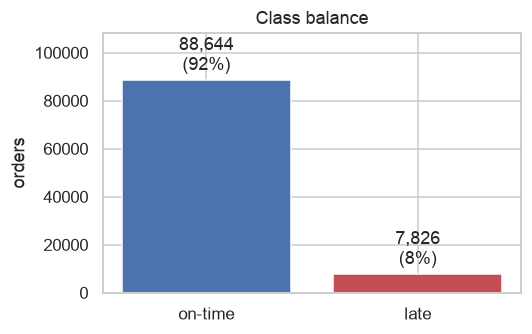

In [38]:
target_labels = {0: "on-time", 1: "late"}
counts = df[TARGET_COLUMN].value_counts().reindex([0, 1], fill_value=0)
late_rate = counts.loc[1] / counts.sum()

print(counts.rename(target_labels))
print(f"\nlate rate: {late_rate:.1%}  (overall delivered-order baseline)")

fig, ax = plt.subplots(figsize=(5, 3.2))
labels = [target_labels[value] for value in counts.index]
bars = ax.bar(labels, counts.values, color=["#4c72b0", "#c44e52"])

ax.set_ylabel("orders")
ax.set_title(f"Class balance")
ax.bar_label(bars, labels=[f"{value:,}\n({value / counts.sum():.0%})" for value in counts.values], padding=3)
ax.set_ylim(0, counts.max() * 1.22)
plt.tight_layout()
plt.show()

> **Insight — late deliveries are uncommon, so accuracy can be misleading.** Only **7,826 of 96,470** delivered orders are late (**8.1%**). If a model simply predicted "on-time" for every order, it would still be **91.9% accurate**, but it would catch **zero** late deliveries. That would not help the business identify shipments that need attention.
>
> So instead of judging the model mainly by accuracy, we use metrics that check whether it can put higher-risk orders near the top of the list:
>
> - **ROC-AUC** asks: if we compare one late order and one on-time order, does the model usually give the late order the higher risk score?
> - **PR-AUC** asks: among the orders the model flags as risky, how many are actually late, and how many late orders does it find? A no-skill PR-AUC equals the positive rate on the sample being evaluated. The overall delivered-order late rate is **8.1%**; final model PR-AUC should be read against the positive rate of the evaluation slice rather than this global rate.
> - **Brier score** checks whether the predicted probabilities are believable. For example, among orders scored as 20% late risk, roughly 20% should actually arrive late.
>
> This also motivates `class_weight="balanced"` in the models and choosing a business-driven alert threshold instead of automatically using 0.5.

## 2. Missingness & summary statistics

Missing values come mostly from left joins (a product/seller/zip not found) and from products with blank physical attributes. Product-category counts and physical totals preserve all-missing product groups as `NaN` rather than silently turning them into zero. The production pipeline in `src/model.py` imputes both numeric and categorical fields before fitting `HistGradientBoostingClassifier`, and the weighted logistic baseline in `02_model.ipynb` also imputes. Worth knowing which columns carry gaps before trusting their distributions.

In [30]:
miss = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
if len(miss):
    display(miss.to_frame("missing_fraction").style.format("{:.2%}"))
else:
    print("No missing values in feature columns.")

,missing_fraction
primary_product_category,1.38%
n_product_categories,1.38%
product_description_length_avg,1.38%
product_photos_qty_avg,1.38%
geo_distance_km,0.50%
product_weight_g_total,0.02%
product_volume_cm3_total,0.02%
payment_type,0.00%
payment_value_total,0.00%
payment_installments_max,0.00%


In [31]:
df[NUMERIC_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
estimated_delivery_days,"96,470.000",23.736,8.761,2.008,18.330,23.231,28.408,155.135
shipping_limit_days,"96,470.000",6.575,4.661,2.004,5.006,6.012,7.136,"1,052.005"
shipping_limit_days_min,"96,470.000",6.561,4.656,2.004,5.006,6.012,7.118,"1,052.005"
shipping_limit_days_range,"96,470.000",0.014,0.321,0.000,0.000,0.000,0.000,25.000
n_unique_shipping_limits,"96,470.000",1.004,0.062,1.000,1.000,1.000,1.000,3.000
purchase_month,"96,470.000",6.031,3.228,1.000,3.000,6.000,8.000,12.000
purchase_dayofweek,"96,470.000",2.756,1.967,0.000,1.000,3.000,4.000,6.000
purchase_hour,"96,470.000",14.773,5.328,0.000,11.000,15.000,19.000,23.000
n_items,"96,470.000",1.142,0.539,1.000,1.000,1.000,1.000,21.000
n_distinct_products,"96,470.000",1.039,0.228,1.000,1.000,1.000,1.000,8.000


## 3. Numeric feature distributions

Many of these are heavy-tailed (price, freight, weight, volume, distance) — useful to know for the linear model (the weighted logistic baseline in `02_model.ipynb`), whose pipeline already standardizes features (and would benefit further from log transforms). For readability we **clip the values** at each feature's 99th percentile before plotting, so the top 1% of observations pile into the rightmost bin (this is a data clip, not just a cropped view — expect a small spike at the top edge).

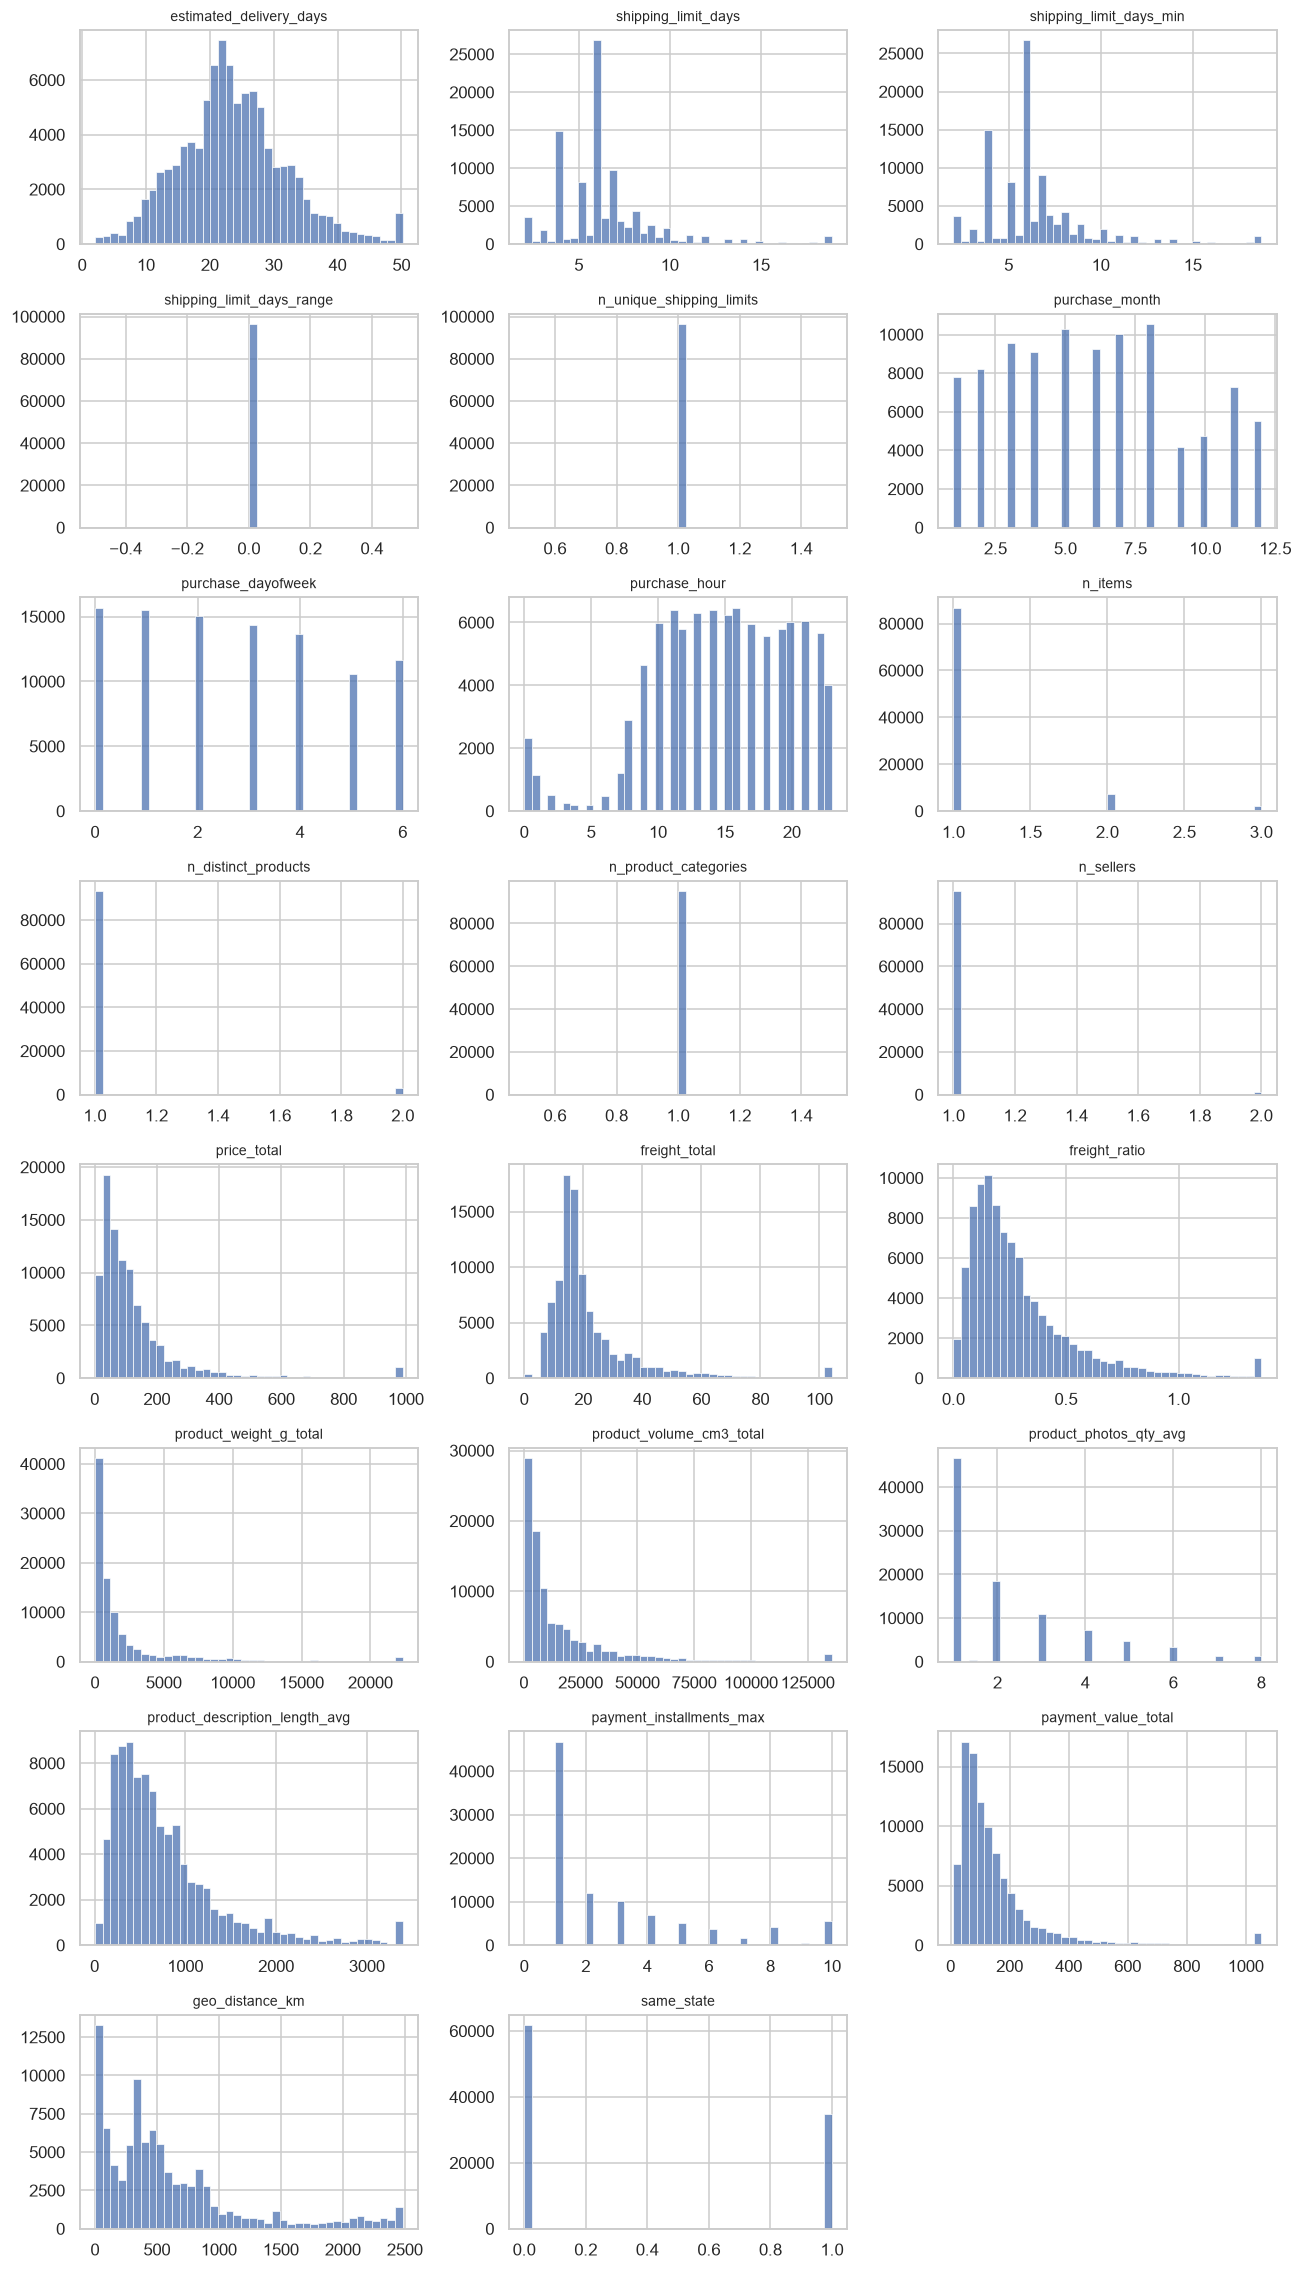

In [32]:
cols = NUMERIC_FEATURES
n = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.6 * nrows))
for ax, col in zip(axes.ravel(), cols):
    s = df[col].dropna()
    hi = s.quantile(0.99)
    sns.histplot(s.clip(upper=hi), bins=40, ax=ax, color="#4c72b0")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## 4. Which features separate late from on-time?

The most informative univariate view for a rare-event problem: bin each numeric feature into deciles and plot the **late rate per bin**. A flat line means no signal; a strong slope means the feature ranks risk well on its own. We expect `estimated_delivery_days` (the promised window) and `geo_distance_km` to show the clearest slopes — though, as the next section quantifies, every univariate effect here is weak. Note the *directions* differ: a longer promised window should trend toward a **lower** late rate (more buffer, so the slope points down), whereas a longer distance should trend toward a higher one.

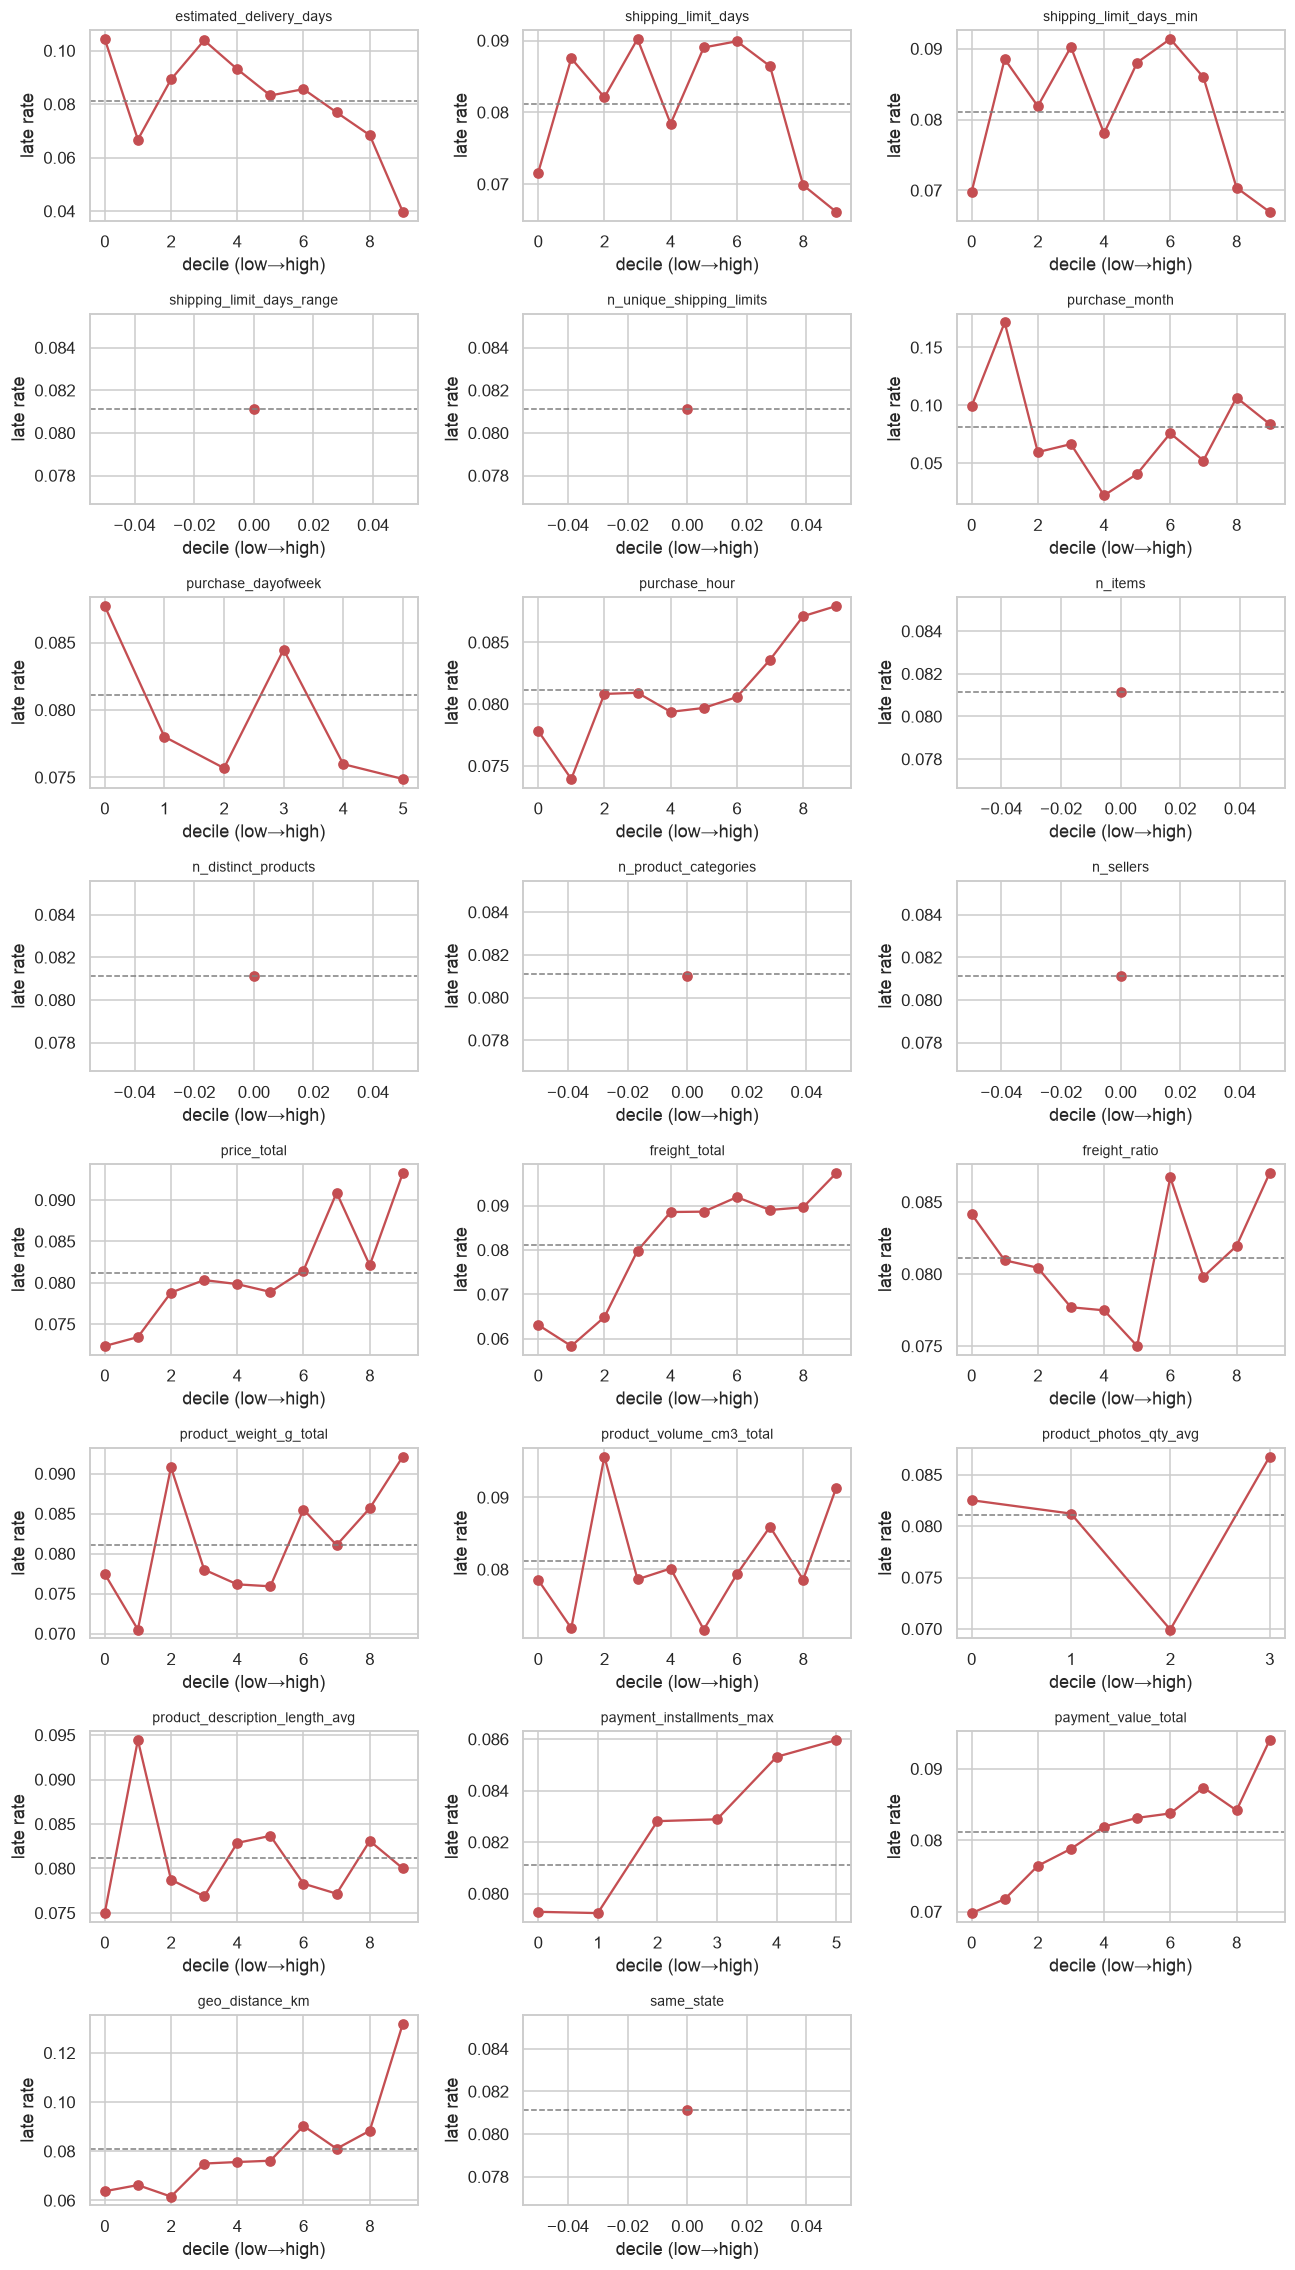

In [33]:
base = df[TARGET_COLUMN].mean()
cols = NUMERIC_FEATURES
n = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.6 * nrows))
for ax, col in zip(axes.ravel(), cols):
    tmp = df[[col, TARGET_COLUMN]].dropna()
    try:
        tmp["bin"] = pd.qcut(tmp[col], q=10, duplicates="drop")
    except ValueError:
        ax.set_visible(False)
        continue
    rate = tmp.groupby("bin", observed=True)[TARGET_COLUMN].mean()
    ax.plot(range(len(rate)), rate.values, marker="o", color="#c44e52")
    ax.axhline(base, ls="--", color="gray", lw=1)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("decile (low→high)")
    ax.set_ylabel("late rate")
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## 5. Correlation with the target (point-biserial) & feature–feature redundancy

A quick ranked view of each numeric feature's linear correlation with `late`, plus a heatmap to spot redundant features (e.g. weight vs. volume, price vs. payment value) that a linear model would double-count.

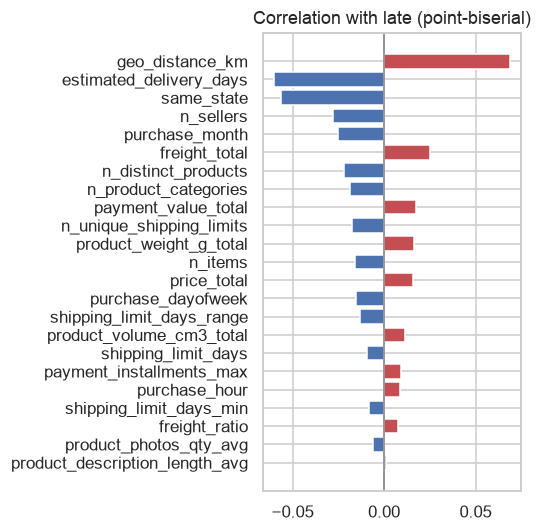

,corr_with_late
geo_distance_km,0.069
estimated_delivery_days,-0.060
same_state,-0.056
n_sellers,-0.028
purchase_month,-0.025
freight_total,0.025
n_distinct_products,-0.022
n_product_categories,-0.019
payment_value_total,0.017
n_unique_shipping_limits,-0.017


In [34]:
corr_t = (
    df[NUMERIC_FEATURES + [TARGET_COLUMN]]
    .corr(numeric_only=True)[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key=np.abs, ascending=False)
)
fig, ax = plt.subplots(figsize=(5, 5))
colors = ["#c44e52" if v > 0 else "#4c72b0" for v in corr_t.values]
ax.barh(corr_t.index[::-1], corr_t.values[::-1], color=colors[::-1])
ax.axvline(0, color="gray", lw=1)
ax.set_title("Correlation with late (point-biserial)")
plt.tight_layout()
plt.show()
corr_t.to_frame("corr_with_late")

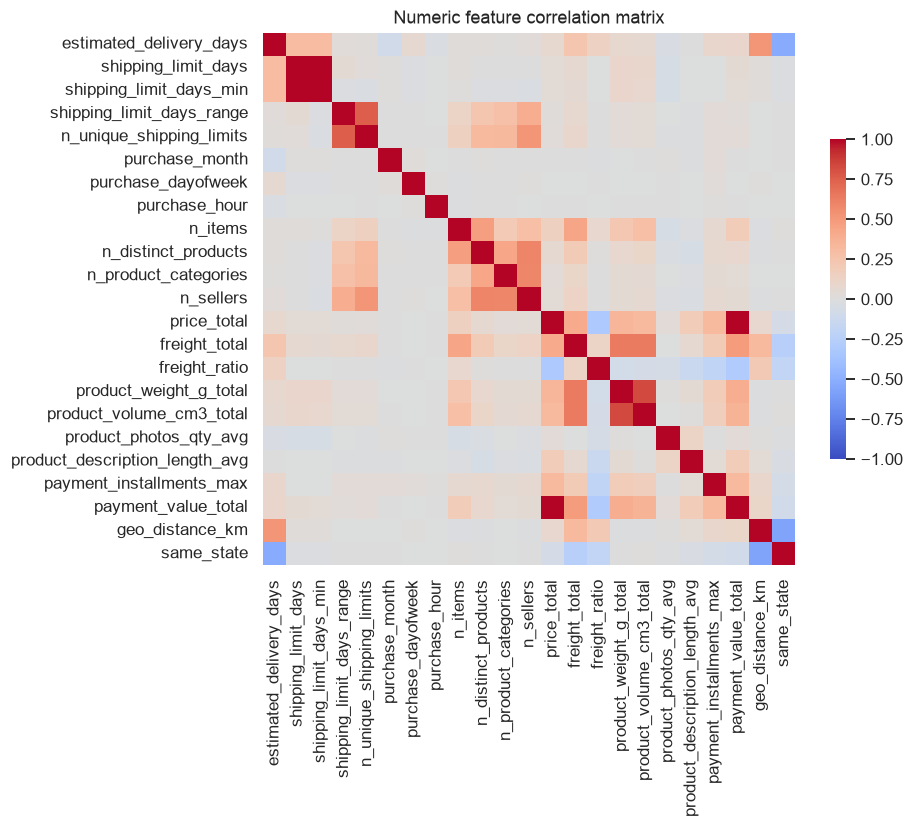

In [35]:
corr = df[NUMERIC_FEATURES].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Numeric feature correlation matrix")
plt.tight_layout()
plt.show()

> **Insight — the signals are weak, and order-complexity features point the "wrong" way.** No single feature separates late from on-time on its own: every point-biserial correlation with `late` is small (|r| ≤ 0.07). The strongest few are at least intuitive — longer `geo_distance_km` (+0.07) and tighter `estimated_delivery_days` (−0.06, i.e. shorter promised windows) go with more late deliveries, and `same_state` orders (−0.06) are less late.
>
> The **unexpected** result is that the *order-complexity* features correlate **negatively** with lateness — `n_sellers` (−0.03), `n_distinct_products` (−0.02), and `n_items` (−0.02) — the opposite of the feature-rationale table, where larger, multi-seller baskets were expected to be *harder* to fulfill and therefore more late-prone. The most likely explanation is confounding: bigger or multi-seller orders may be granted more generous estimated windows or ship from better-resourced sellers, which offsets the added complexity. Either way, these weak and sometimes counterintuitive univariate effects are exactly why the modeling leans on multivariate, non-linear models instead of trusting any one column.

## 6. Categorical feature signal

Categorical fields can carry useful logistics signal, but several are high-cardinality (`customer_city`, `seller_city`, product category). To keep the view stable, this section only compares categories with at least 100 orders and shows the highest-risk values by late rate. The `lift_vs_base` column is the category late rate divided by the overall late rate.

,feature,category,orders,late_rate,lift_vs_base
88,customer_city,maceio,236,29.7%,3.66x
134,customer_city,sao goncalo,385,24.9%,3.07x
42,customer_city,cabo frio,113,23.9%,2.95x
141,customer_city,sao luis,335,22.4%,2.76x
151,customer_city,teresina,271,22.1%,2.73x
135,customer_city,sao joao de meriti,124,21.8%,2.68x
72,customer_city,hortolandia,142,21.1%,2.60x
100,customer_city,nova friburgo,142,21.1%,2.60x
0,customer_state,AL,397,23.9%,2.95x
7,customer_state,MA,717,19.7%,2.42x


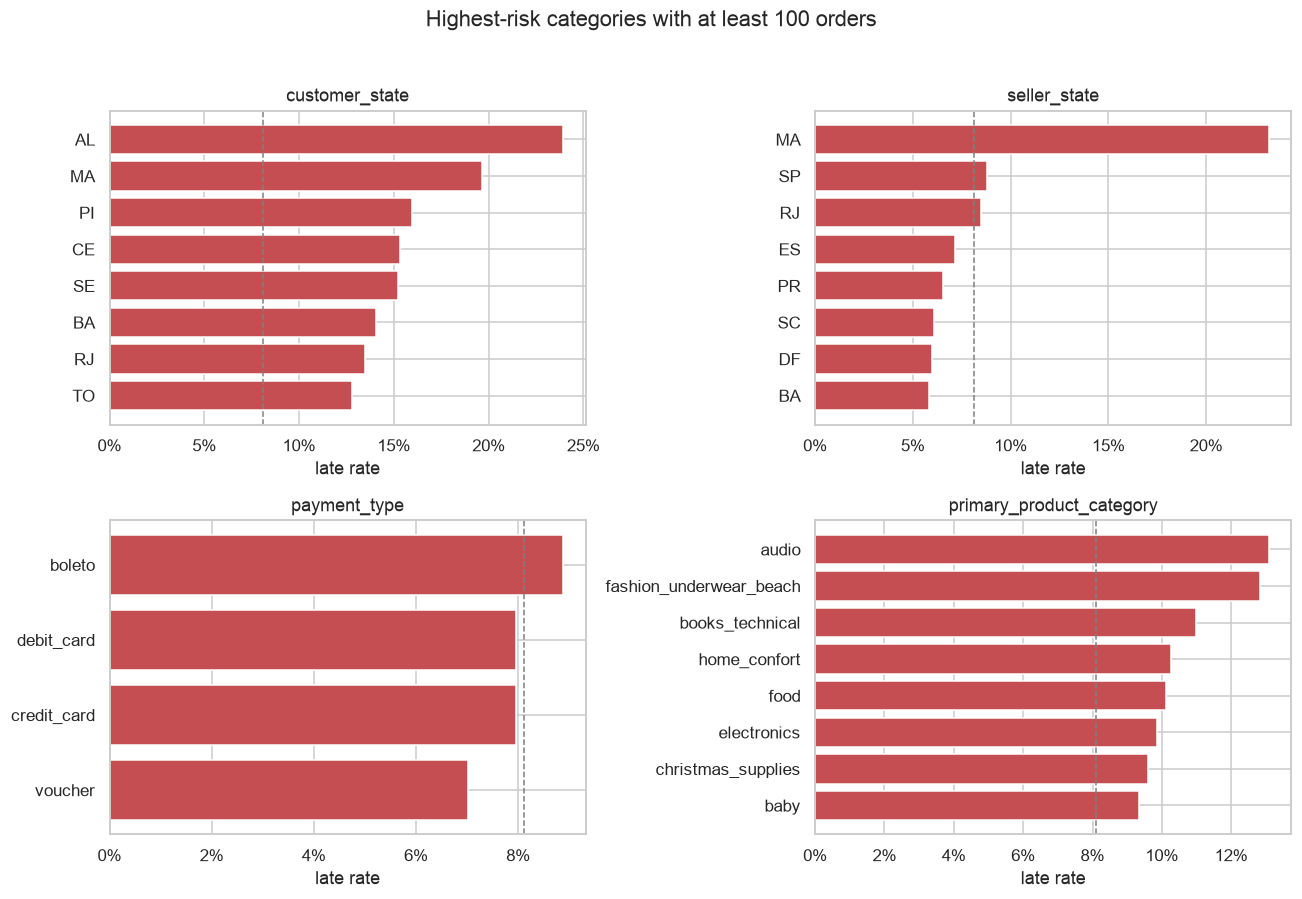

In [36]:
MIN_CATEGORY_ORDERS = 100
TOP_N_CATEGORIES = 8
base_late_rate = df[TARGET_COLUMN].mean()

categorical_summaries = []
for feature in CATEGORICAL_FEATURES:
    summary = (
        df.groupby(feature, dropna=False)[TARGET_COLUMN]
        .agg(orders="size", late_rate="mean")
        .reset_index()
    )
    summary = summary[summary["orders"] >= MIN_CATEGORY_ORDERS].copy()
    summary["feature"] = feature
    summary["lift_vs_base"] = summary["late_rate"] / base_late_rate
    summary = summary.rename(columns={feature: "category"})
    categorical_summaries.append(summary)

cat_signal = pd.concat(categorical_summaries, ignore_index=True)
cat_signal["category"] = cat_signal["category"].astype("string").fillna("missing")
cat_signal = cat_signal.sort_values(
    ["feature", "late_rate", "orders"], ascending=[True, False, False]
)

display(
    cat_signal.groupby("feature", group_keys=False)
    .head(TOP_N_CATEGORIES)
    .loc[:, ["feature", "category", "orders", "late_rate", "lift_vs_base"]]
    .style.format({"late_rate": "{:.1%}", "lift_vs_base": "{:.2f}x", "orders": "{:,.0f}"})
)

plot_features = [
    "customer_state",
    "seller_state",
    "payment_type",
    "primary_product_category",
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, feature in zip(axes, plot_features):
    top = (
        cat_signal[cat_signal["feature"] == feature]
        .nlargest(TOP_N_CATEGORIES, "late_rate")
        .sort_values("late_rate")
    )
    ax.barh(top["category"], top["late_rate"], color="#c44e52")
    ax.axvline(base_late_rate, color="gray", linestyle="--", linewidth=1)
    ax.set_title(feature)
    ax.set_xlabel("late rate")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

fig.suptitle(f"Highest-risk categories with at least {MIN_CATEGORY_ORDERS:,} orders", y=1.02)
plt.tight_layout()
plt.show()

## 7. Is the signal stable over time?

Because we evaluate with a **chronological** train/test split, a large drift in the late rate between the early (train) and recent (test) periods would hurt any model. Here we plot the monthly late rate and order volume to check for regime shifts (e.g. the late-2017 demand spike).

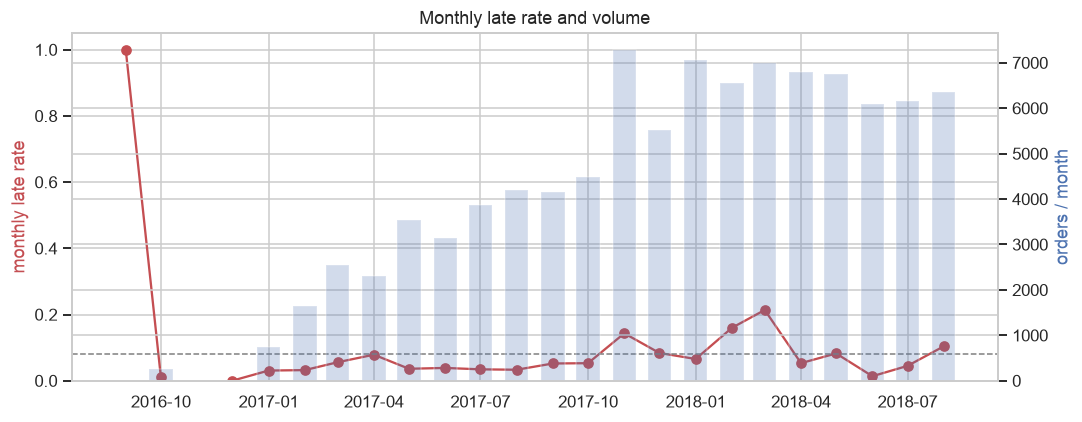

In [37]:
monthly = (
    df.set_index(TIME_COLUMN)
    .resample("MS")[TARGET_COLUMN]
    .agg(["mean", "count"])
)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(monthly.index, monthly["mean"], marker="o", color="#c44e52", label="late rate")
ax1.axhline(df[TARGET_COLUMN].mean(), ls="--", color="gray", lw=1)
ax1.set_ylabel("monthly late rate", color="#c44e52")
ax1.set_ylim(0, None)
ax2 = ax1.twinx()
ax2.bar(monthly.index, monthly["count"], width=20, alpha=0.25, color="#4c72b0")
ax2.set_ylabel("orders / month", color="#4c72b0")
ax1.set_title("Monthly late rate and volume")
plt.tight_layout()
plt.show()

## Notes
- **Primary-seller geography caveat:** `geo_distance_km`, `same_state`, `seller_state`, and `seller_city` are computed from the first line item's seller (`primary_seller_id`). For the small share of multi-seller orders (`n_sellers > 1`), these fields describe one origin rather than every seller in the order; all sellers exist in the raw item data, but this notebook collapses geography to a single primary seller for order-level modeling.
